# Задача о многоруком бандите

Продемонстрируем работу различных стратегий выбора действий в задаче о многоруком бандите:

- **𝜺-жадные** стратегии
- стратегии на основе **ВДГ-действий**
- **SoftMax**-стратегия
- стратегия на основе **выборки Томпсона**

На каждом шаге эти стратегии по-разному принимают решение: использовать ли имеющейся опыт или провести исследование.

### Код работы среды: многорукий бандит

Для сравнения стратегий удобно задать многорукого бандита в виде класса.

При инициализации:

- задаётся число рычагов `k`
- задаются или генерируются истинные ценности рычагов `q_true`
- есть возможность задать нестационарную среду – если флаг `Q_changed=True`, то при каждом временном шаге значения `q_true` немного смещаются случайным образом, меняя тем самым оптимальное действие.

Методы:

- `reset()` – ре-инициализация `q_true`.
- `step(action)` – выдаёт вознаграждение, взятое из нормального распределения с центром в `q_true[action]` и дисперсией 1.

Также есть возможность установить начальные значения оценок ценностей.

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm

class Bandit:
    # k: число вычагов
    # Q_changed: флаг, меняются ли истинные ценности действий
    # q_true: задание истинных ценностей, при необходимости
    def __init__(self, k = 10, Q_changed = False, q_true = None):
        self.k = k
        self.Q_changed = Q_changed
        if q_true is None:
            self.q_true = np.random.randn(k)
        else:
            assert isinstance(q_true, np.ndarray), "q_true must be a NumPy array"
            assert len(q_true) == k, "q_true must have length k"
            self.q_true = q_true
        # истинное лучшее действие   
        self.best_action = np.argmax(self.q_true)        
        
    def reset(self, q_true = None):
        if q_true is None:
            self.q_true = np.random.randn(self.k)
        else:
            self.q_true = q_true
        self.best_action = np.argmax(self.q_true)

    # осуществление действия, получение вознаграждения
    def step(self, action):
        # изменение истинных ценностей
        if self.Q_changed == True:
            self.q_true +=  np.random.normal(0, 0.01, self.k)
            self.best_action = np.argmax(self.q_true)
        # вознаграждение из нормального распределения N(q_true[action], 1)
        reward = np.random.randn() + self.q_true[action]
        return reward

### Код работы агентов

Поскольку тестировать будем несколько стратегий, то удобно воспользоваться абстрактным классом-заготовкой для агента.

Важные поля - это

- `self.action_values` - массив оценок ценностей действий,
- `self.action_counts` - массив с числом выборов действий.

Метод `reset()` позволяет сбросить эти поля к начальным значениям.

Для каждой стратегии надо сформировать класс наследник с методами:

- `get_action()` - правило выбора действия,
- `update(action, reward)` - правило обновления оценок.

Метод `learn(n_steps)` запускает симуляцию взаимодействия агента со средой на протяжении `n_steps` шагов; этот метод возвращает историю полученных наград и флаги выбора лучшего действия на каждом шаге, что позволит оценить качество обучения по выбранной стратегии.

In [2]:
from abc import ABC, abstractmethod

class AgentMAB(ABC):
    def __init__(self, bandit, initial_values=0.):
        self.bandit = bandit
        self.k = bandit.k                     # число действий
        self.actions = np.arange(self.k)      # индексы действий
        self.init_values = initial_values
        self.action_values = np.zeros(self.k) + self.init_values # оценки ценностей
        self.action_counts = np.zeros(self.k) # счётчики выборов

    def reset(self):
        self.action_values = np.zeros(self.k) + self.init_values
        self.action_counts = np.zeros(self.k)

    @abstractmethod
    def get_action(self):
        """Выбрать действие на основе текущих оценок."""
        pass

    @abstractmethod
    def update(self, action, reward):
        """Обновить оценки на основе полученного вознаграждения."""
        pass

    # запуск обучения 
    def learn(self, n_steps):
        rewards = np.zeros(n_steps) #массив вознаграждений
        best_action_counts = np.zeros(rewards.shape) #массив с метками о выборе лучшего действия
        for t in range(n_steps):
            a = self.get_action() # действие
            r = self.bandit.step(a) # получение вознаграждения
            self.update(a,r) # обновление оценок
            rewards[t] = r
            if a == bandit.best_action:
                best_action_counts[t] = 1
        return rewards, best_action_counts

Для работы некоторых стратегий надо формировать оценки ценности действий. Напомним, что оценки ценности действия формируются усредненим всех вознаграждений, полученных за выбор этого действия. Для вычисления этого выборочного среднего используем формулу

$Q_{n} = Q_{n-1} + \frac 1n (r_n - Q_{n-1}),$

где 
- $r_n$ обозначает вознаграждение, которое получено после $n$-го по счёту выбора этого рычага,
- $Q_{n-1}$ обозначает оценку ценности этого рычага после его выбора $n-1$ раз.

Либо же можно использовать формулу с постоянной скоростью обучения $\alpha$

$Q_{n} = Q_{n-1} + \alpha (r_n - Q_{n-1}).$

#### $\varepsilon$-жадная стратегия

Технически, 𝜺-жадная стратегия реализуется следующим образом.

1. Генерируется случайное число между нулём и единицей и сравнивается с параметром 𝜺. 
2. Если значение оказывается меньше 𝜺, то проводится исследование, то есть выбирается один рычаг из десяти равновероятно. 
3. Если же значение оказывается больше 𝜺, то используем жадный алгоритм, который выбирает максимальное значение из уже известных оценок (если таких несколько, то выбор случаен). 

In [14]:
class EpsilonGreedyAgent(AgentMAB):
    def __init__(self, bandit, epsilon=0.1, alpha=None, initial_values=0.0):
        super().__init__(bandit, initial_values = initial_values)
        self.epsilon = epsilon
        self.alpha = alpha       

    def get_action(self):
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)
        return np.argmax(self.action_values)

    def update(self, action, reward):
        self.action_counts[action] += 1
        if self.alpha is None:
            # обновление по формуле выборочных средних
            self.action_values[action] += (reward - self.action_values[action]) / self.action_counts[action]
        else:
            # обновление с постоянным шагом
            self.action_values[action] += (reward - self.action_values[action]) * self.alpha

#### Стратегия на основе ВДГ-действий

In [15]:
class UCBAgent(AgentMAB):
    def __init__(self, bandit, confidence=2.0, alpha=None, initial_values=0.0):
        super().__init__(bandit, initial_values = initial_values)
        self.confidence = confidence          # параметр c в формуле UCB
        self.alpha = alpha                    # шаг для постоянного обновления
        self.time = 0                         # общий счётчик шагов

    def reset(self):
        super().reset()
        self.time = 0                         # сбрасываем счётчик при перезапуске

    def get_action(self):
        # Вычисляем UCB-оценку для каждого действия
        ucb_values = self.action_values + self.confidence * np.sqrt(
            np.log(self.time + 1) / (self.action_counts + 1e-5)
        )
        return np.argmax(ucb_values)

    def update(self, action, reward):
        self.time += 1
        self.action_counts[action] += 1
        if self.alpha is None:
            # обновление по формуле выборочных средних
            self.action_values[action] += (reward - self.action_values[action]) / self.action_counts[action]
        else:
            # обновление с постоянным шагом
            self.action_values[action] += (reward - self.action_values[action]) * self.alpha

### Проверки

In [16]:
   # проверка 1
bandit = Bandit(10)
agent = EpsilonGreedyAgent(bandit)
bandit.reset()
agent.reset()
print("Истинные ценности: ",bandit.q_true)
print("Лучший рычаг (нумерация с 0): ",bandit.best_action)
print("\
      ")
a = agent.get_action()
r = bandit.step(a)
agent.update(a,r)
print("Шаг 1. Выбор рычага по eps-жадной стратегии: ", a)
print("Полученная награда", r)
print("Вектор оценок", agent.action_values)

a = agent.get_action()
r = bandit.step(a)
agent.update(a,r)
print("Шаг 2. Выбор рычага по eps-жадной стратегии: ", a)
print("Полученная награда", r)
print("Вектор оценок", agent.action_values)

Истинные ценности:  [-0.94687069 -0.13157383 -0.74092761 -0.48139329  0.4834829   0.05851907
 -0.13360799 -0.30999243  0.08344833  0.84533424]
Лучший рычаг (нумерация с 0):  9
      
Шаг 1. Выбор рычага по eps-жадной стратегии:  0
Полученная награда -1.2020624725927551
Вектор оценок [-1.20206247  0.          0.          0.          0.          0.
  0.          0.          0.          0.        ]
Шаг 2. Выбор рычага по eps-жадной стратегии:  1
Полученная награда 0.7873454885020624
Вектор оценок [-1.20206247  0.78734549  0.          0.          0.          0.
  0.          0.          0.          0.        ]


In [17]:
# проверка 2
bandit.reset()
agent.reset()
actions = []
for i in range(10):
    a = agent.get_action()
    r = bandit.step(a)
    agent.update(a,r)
    actions.append(a)
print("Массив выбранных действий за 10 шагов:", actions)
print("Массив оценок после 10 шагов:", agent.action_values)

Массив выбранных действий за 10 шагов: [np.int64(0), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1), np.int64(1)]
Массив оценок после 10 шагов: [-1.44709496  1.64124521  0.          0.          0.          0.
  0.          0.          0.          0.        ]


### Сравнение стратегий

Продемонстрируем процесс обучения различных стратегий на примере задачи о k-руком бандите. 

Симуляции будем проводить на примере бандита с 10-ю рычагами на протяжении 1000 шагов.

Процесс работы агента и генерация вознаграждений зависит от ряда случайных параметров. Чтобы получить объективное представление о работе стратегий **необходимо много эпизодов взаимодействия агента с бандитом.**

До начала эпизода при вызове `Bandit.reset()` инициализируется массив истинных ценностей `q_true` путём генерации 10 чисел нормально распределённых со средним 0 и стандартным отклонением 1. Далее, агент методом `Agent.learn()` взаимодействует с бандитом в течении 1000 временных шагов. После каждого эпизода формируется два массива:
1. массив полученных вознаграждений в течении 1000 шагов;
2. бинарный массив длины 1000, где единицами отмечены выборы действия с максимальной истинной ценностью. 

Проведём 2000 эпизодов обучения и усредним полученные массивы. Тем самым, получим информацию о среднем вознаграждении и о среднем проценте выбора оптимальных действий за каждый временной шаг, что позволит сравнить стратегии.

Указанные выше шаги реализованы в методе `bandit_simulation()`.

In [18]:
# специальная функция для запуска многих эпизодов симуляции, 
def bandit_simulation(bandit, agent, runs, n_steps):
    mean_rewards = np.zeros(n_steps) #массив вознаграждений
    mean_best_choices = np.zeros(mean_rewards.shape) #массив с метками о выборе лучшего действия
    for _ in tqdm(range(runs)):
        # сброс полей
        bandit.reset()
        agent.reset()
        # запуск эпизода
        rewards, best_action_counts = agent.learn(n_steps)
        mean_rewards += rewards
        mean_best_choices += best_action_counts
        
    return mean_rewards/runs, mean_best_choices/runs

100%|██████████| 20/20 [00:00<00:00, 156.60it/s]

Число шагов: 1000


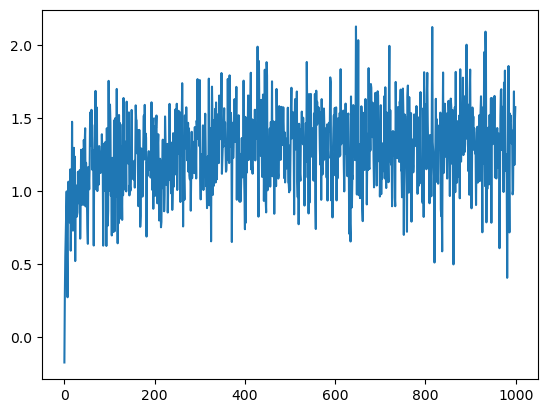

In [19]:
# проверка работы
runs=20
n_steps=1000
bandit = Bandit(10)
agent = EpsilonGreedyAgent(bandit)

rewards, best_action_counts = bandit_simulation(bandit, agent, runs, n_steps)
print("Число шагов:", len(rewards))
plt.plot(rewards, label='epsilon')

#### Сравнение 𝜺-жадной и жадной стратегии

Сначала рассмотрим работу двух стратегий: жадной и 𝜺-жадной с разными значениями 𝜺. 
Запустим симуляцию и выведем результаты симуляции на графиках.

In [20]:
# Запуск 2000 прогонов
runs = 2000
n_steps=1000
bandit = Bandit(10)
epsilons = [0, 0.01, 0.1, 0.25]
agents = [EpsilonGreedyAgent(bandit, epsilon = eps) for eps in epsilons]
rewards = np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:16<00:00, 119.87it/s]


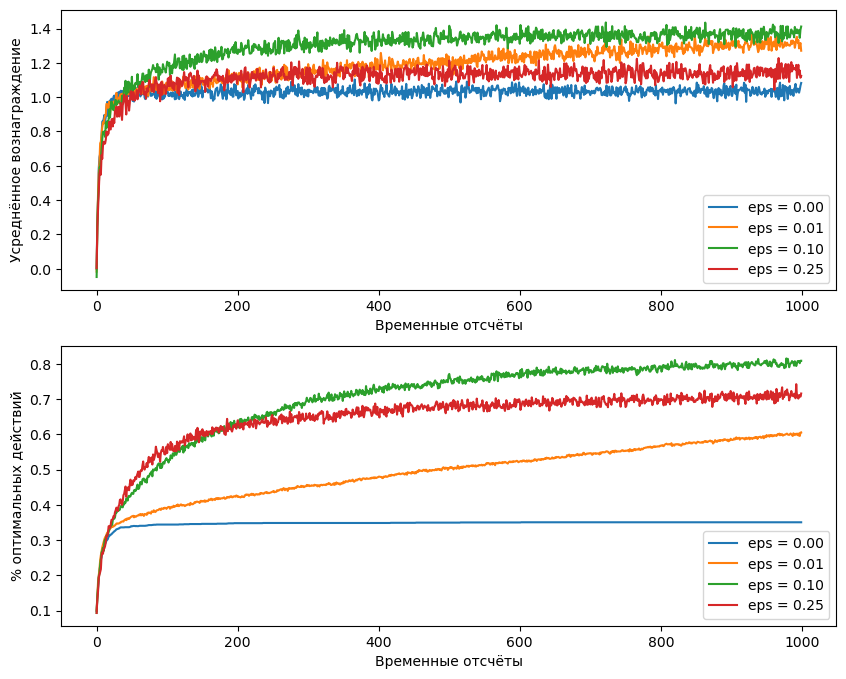

In [18]:
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)
for eps, rews in zip(epsilons, rewards):
    plt.plot(rews, label='eps = %.02f' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
for eps, opts in zip(epsilons, best_action_counts):
    plt.plot(opts, label='eps = %.02f' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Как ясно из симуляции, чистая жадная стратегия уступает $\varepsilon$-жадным стратегиям, поскольку при отсутствии хороших оценок жадная стратегия не всегда позволяет выявить оптимальное действие.

$\varepsilon$-жадные стратегии для различных $\varepsilon$ также показывают несколько различные результаты. 
Стратегия со сравнительно большим $\varepsilon$ быстрее находит оптимальное действие, однако, оно выбирается с вероятностью $1-\varepsilon$. На длительной дистанции стратегии со сравнительно малым $\varepsilon$ обгонят по получаемым вознаграждениям стратегии со сравнительно большим $\varepsilon$, поскольку они чаще выбирают оптимальное действие.

 ### Стратегии с оптимистичным стартом
 
Сравним работу $\varepsilon$-жадной и жадной стратегий с оптимистическими стартами (завышенные начальные оценки) и без них.

In [19]:
# Запуск 2000 прогонов
runs = 2000
n_steps = 1000
bandit = Bandit(10)

agents = []

agents.append(EpsilonGreedyAgent(bandit, epsilon=0))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0, initial_values=5))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1, initial_values=5))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:12<00:00, 160.30it/s]


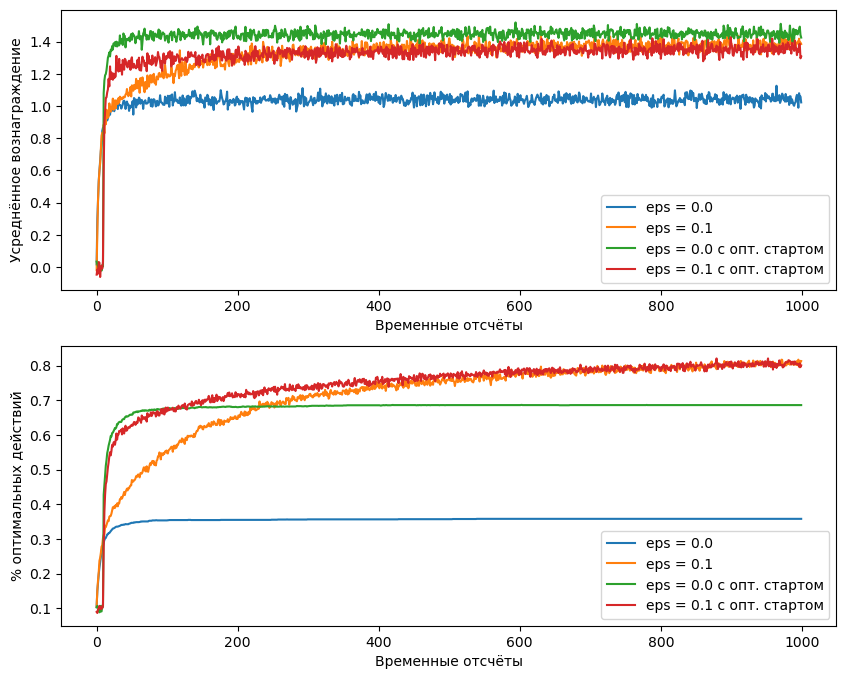

In [20]:
epsilons = [0, 0.1]
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)

plt.plot(rewards[0], label='eps = %.01f' % (0))
plt.plot(rewards[1], label='eps = %.01f' % (0.1))
plt.plot(rewards[2], label='eps = %.01f с опт. стартом' % (0))
plt.plot(rewards[3], label='eps = %.01f с опт. стартом' % (0.1))
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.01f' % (0))
plt.plot(best_action_counts[1], label='eps = %.01f' % (0.1))
plt.plot(best_action_counts[2], label='eps = %.01f с опт. стартом' % (0))
plt.plot(best_action_counts[3], label='eps = %.01f с опт. стартом' % (0.1))
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Для жадной стратегии наличие оптимистичного старта позволяет существенно увеличить среднее вознаграждение и процент выбора оптимальных действий. Но и так не всегда жадная стратегия выявляет оптимальное действие.

Для $\varepsilon$-жадной стратегии наличие оптимтичного старта позволяет лишь быстрее выявить хорошее действие, но далее оптимистичный старт не влияет на среднее вознаграждение и процент выбора оптимальных действий

Можно также отметить, что при $\varepsilon=0.1$ среднее вознаграждение получается ниже, чем при жадной стратегии с оптимистичным стартом, хотя процент выбора оптимального действия выше. Это связано с тем, что всё-таки в 10% случаев выбирается случайное действие и это снижает среднее вознаграждение. Если снизить $\varepsilon$, например, до $0.01$, то среднее вознаграждение для $\varepsilon$-жадной стратегии будет выше, чем у жадной стратегии.

In [21]:
# Запуск 2000 прогонов
runs = 2000
n_steps = 1000
bandit = Bandit(10)

agents = []
agents.append(EpsilonGreedyAgent(bandit, epsilon=0, initial_values=5))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.01, initial_values=5))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:09<00:00, 202.13it/s]


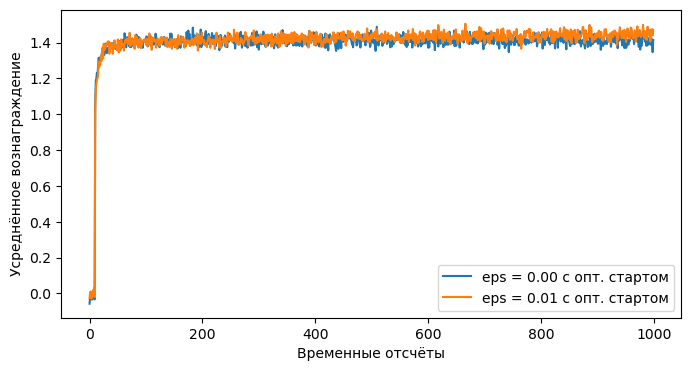

In [22]:
epsilons = [0, 0.01]
plt.figure(figsize=(8,4))     
for i, eps in enumerate(epsilons):
    plt.plot(rewards[i], label='eps = %.02f с опт. стартом' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

Выведем также график процента выбора оптимальных действий для 50 начальных временных шагов.

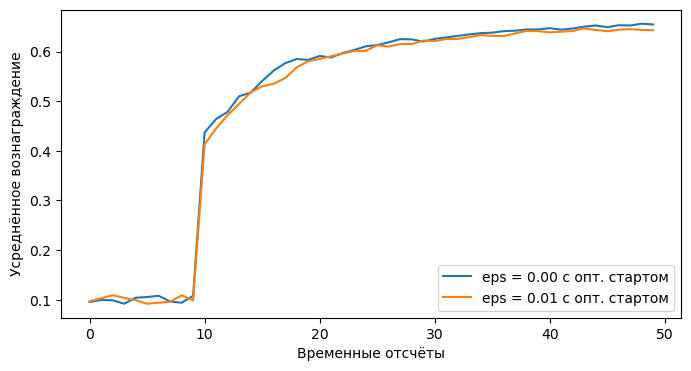

In [23]:
plt.figure(figsize=(8,4))     
for i, eps in enumerate(epsilons):
    plt.plot(best_action_counts[i][0:50], label='eps = %.02f с опт. стартом' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

На этом графике видно, что процент выбора оптимальных действий резко подрастает на 10 отсчёте. Это вполне ожидаемо, так как после того как опробованы все 10 рычагов, самая большая оценка ценности чаще всего будет у рычага с самым большим истинным вознаграждением.

#### Сравнение стратегий в нестационарном случае

Нестационарный случай значит, что с течением времени изменяются истинные вознаграждения `q_true`.
Продемонстрируем, что постоянный размер шага обучения $\alpha$ лучше подходит для этого случая, чем вычисление оценок по методу выборочного среднего (то есть когда $\alpha = \frac 1n$, где $n$ число выборов действия).


In [25]:
runs = 2000
n_steps = 1000
bandit = Bandit(10, Q_changed = True)

epsilons = [0, 0.1]

agents = []
for eps in epsilons:
    agents.append(EpsilonGreedyAgent(bandit, epsilon=eps))
    agents.append(EpsilonGreedyAgent(bandit, epsilon=eps, alpha = 0.1))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:23<00:00, 85.82it/s]


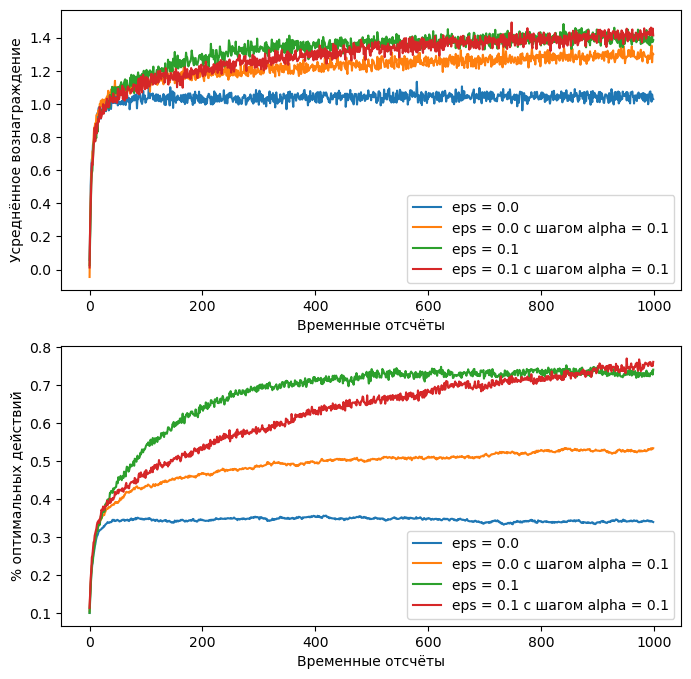

In [26]:
plt.figure(figsize=(8,8))     
plt.subplot(2, 1, 1)
for i, eps in enumerate(epsilons):
    plt.plot(rewards[2*i], label='eps = %.01f' % (eps))
    plt.plot(rewards[2*i+1], label='eps = %.01f с шагом alpha = 0.1' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
for i, eps in enumerate(epsilons):
    plt.plot(best_action_counts[2*i], label='eps = %.01f' % (eps))
    plt.plot(best_action_counts[2*i+1], label='eps = %.01f с шагом alpha = 0.1' % (eps))
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Как и ожидалость, формирование оценок ценностей с постоянным шагом обучения показывает более хороший результат в условиях, когда истинные ценности меняются.

#### Сравнение c ВДГ-стратегией

Продемонстрируем сравнение -жадной стратегии и стратегии, основанной на ВДГ-действии. 

Проведём симуляцию с тремя стратегиями:
1. $\varepsilon$-жадной стратегии с $\varepsilon = 0.05$;
2. $\varepsilon$-жадной стратегии с $\varepsilon = 0.1$;
3. Стратегия на основе ВДГ-действий.

In [27]:
runs = 2000
n_steps = 1000
bandit = Bandit(10)
agents = []

agents.append(EpsilonGreedyAgent(bandit, epsilon=0.05))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1))
agents.append(UCBAgent(bandit))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:23<00:00, 86.77it/s]


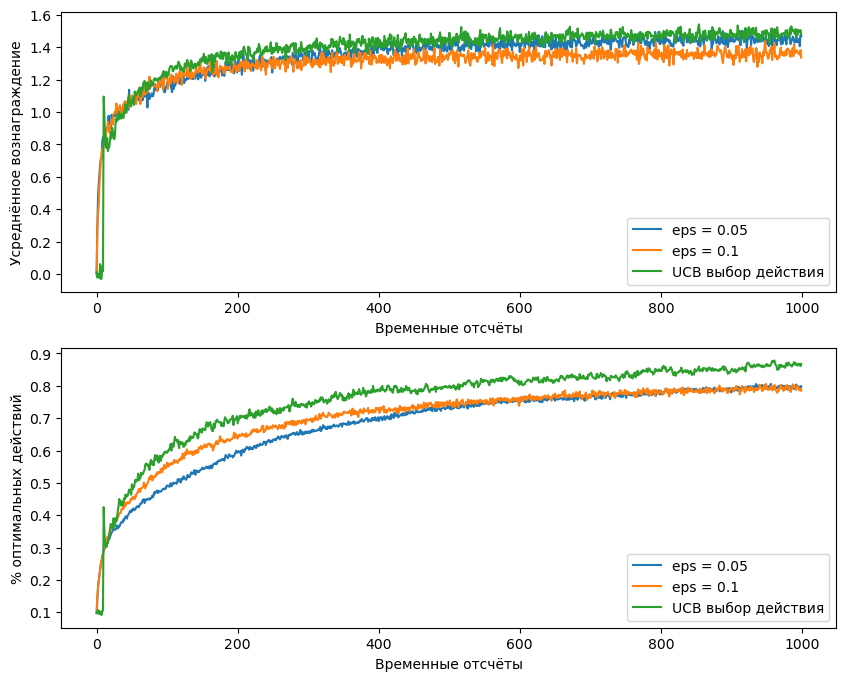

In [28]:
plt.figure(figsize=(10,8))  
plt.subplot(2, 1, 1)
plt.plot(rewards[0], label='eps = %.02f' % (0.05))
plt.plot(rewards[1], label='eps = %.01f' % (0.1))
plt.plot(rewards[2], label='UCB выбор действия')
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.02f' % (0.05))
plt.plot(best_action_counts[1], label='eps = %.01f' % (0.1))
plt.plot(best_action_counts[2], label='UCB выбор действия')
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

В данном случае стратегия на основе ВДГ-действий показывает более лучший результат.

Рассмотрим также аналогичную симуляцию, когда истинные ценности со временем изменяются.

In [29]:
runs = 2000
n_steps = 1000
bandit = Bandit(10, Q_changed = True)
agents = []

agents.append(EpsilonGreedyAgent(bandit, epsilon=0.05, alpha = 0.1))
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1, alpha = 0.1))
agents.append(UCBAgent(bandit, alpha = 0.1))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:34<00:00, 58.69it/s]


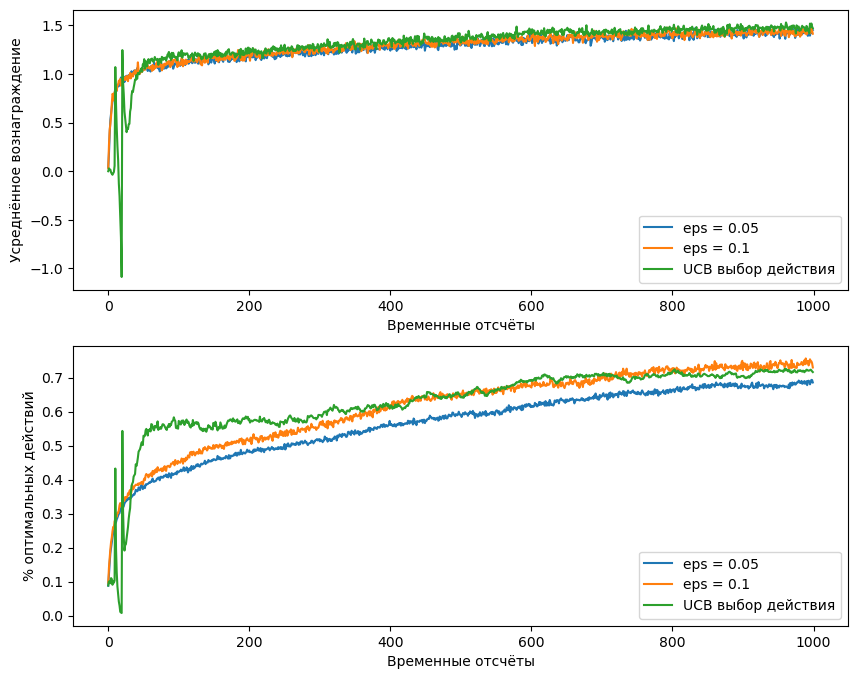

In [30]:
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)
plt.plot(rewards[0], label='eps = %.02f' % (0.05))
plt.plot(rewards[1], label='eps = %.01f' % (0.1))
plt.plot(rewards[2], label='UCB выбор действия')
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.02f' % (0.05))
plt.plot(best_action_counts[1], label='eps = %.01f' % (0.1))
plt.plot(best_action_counts[2], label='UCB выбор действия')
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Как видно из симуляций, стратегия на основе ВДГ-действий хуже себя показывает в задаче нахождения оптимального действия при изменяющихся истинных ценностях.

### Сравнение c SoftMax-стратегией

Продемонстрируем сравнение $\varepsilon$-жадной стратегии, стратегии ВДГ-действий и SoftMax-стратегии.

Проведём симуляцию с 4 стратегиями:
1. $\varepsilon$-жадной стратегии с $\varepsilon = 0.05$;
2. Стратегия на основе ВДГ-действий.
3. Стратегия на softmax-исследования с $\tau = 0.125$.
4. Стратегия на softmax-исследования с $\tau = 0.175$.

### *ЗАДАЧА*: дописать код агента с выбором действий на основе SoftMax-исследования.

In [72]:
class SoftMaxAgent(AgentMAB):
    def __init__(self, bandit, epsilon=0.1, alpha=None, initial_values=0.0, tau = 0.1):
        super().__init__(bandit, initial_values = initial_values)
        pass

    def get_action(self):
        pass

    def update(self, action, reward):
        pass

In [86]:
runs=2000
time=1000
bandit = Bandit(10)
#bandit = Bandit(10, Q_changed = True)

agents = []
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.05))
agents.append(UCBAgent(bandit))
agents.append(SoftMaxAgent(bandit, tau = 0.125))
agents.append(SoftMaxAgent(bandit, tau = 0.175))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [01:23<00:00, 23.99it/s]


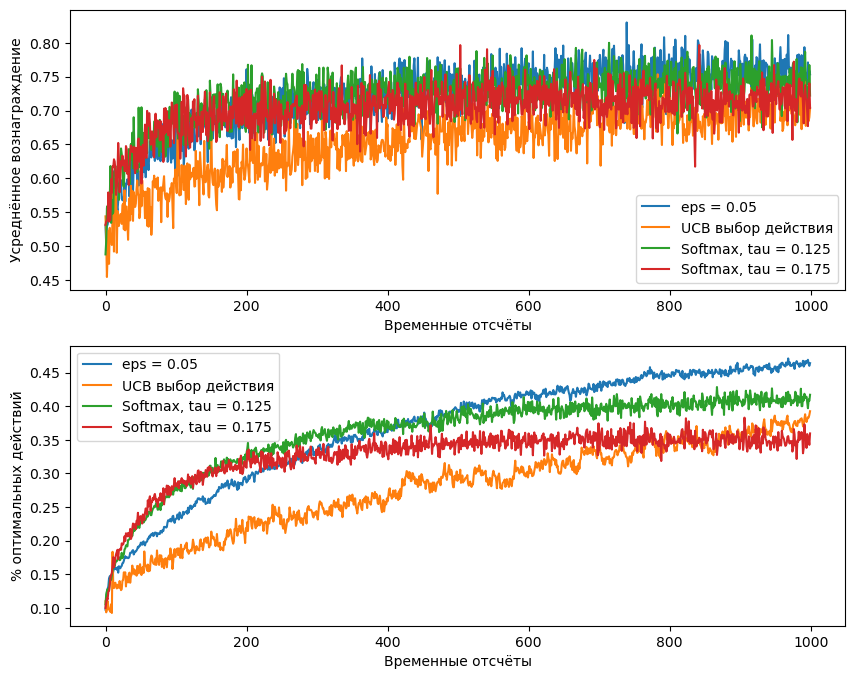

In [87]:
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)
plt.plot(rewards[0], label='eps = %.02f' % (0.05))
plt.plot(rewards[1], label='UCB выбор действия')
plt.plot(rewards[2], label='Softmax, tau = 0.125')
plt.plot(rewards[3], label='Softmax, tau = 0.175')
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.02f' % (0.05))
plt.plot(best_action_counts[1], label='UCB выбор действия')
plt.plot(best_action_counts[2], label='Softmax, tau = 0.125')
plt.plot(best_action_counts[3], label='Softmax, tau = 0.175')
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Работа SoftMax-исследования сильно зависит от правильной настройки температурного параметра.

### Cтратегия на основе выборки Томпсона

Сравним работу $\varepsilon$-жадной стратегии и стратегии на основе выборки Томпсона. Напомним, что стратегия на основе выборки Томпсона применяется в несколько изменённой постановке.

Истинные ценности действий или рычагов - это теперь числа от 0 до 1. Вознаграждение за выбор того или иного рычага - это либо 0, либо 1, причём 1 возвращается с вероятностью, равной истинной ценности этого рычага.

Для этого изменим метод `bandit_simulation()`.

In [34]:
class Bandit_TS:
    # k: число вычагов
    # Q_changed: флаг, меняются ли истинные ценности действий
    # q_true: задание истинных ценностей, при необходимости
    def __init__(self, k = 10, Q_changed = False, q_true = None):
        self.k = k
        self.Q_changed = Q_changed
        if q_true is None:
            self.q_true = np.random.randn(k)
        else:
            assert isinstance(q_true, np.ndarray), "q_true must be a NumPy array"
            assert len(q_true) == k, "q_true must have length k"
            self.q_true = q_true
        # истинное лучшее действие   
        self.best_action = np.argmax(self.q_true)        
        
    def reset(self, q_true = None):
        if q_true is None:
            self.q_true = np.random.randn(self.k)
        else:
            self.q_true = q_true
        self.best_action = np.argmax(self.q_true)

    # осуществление действия, получение вознаграждения
    def step(self, action):
        # изменение истинных ценностей
        if self.Q_changed:
            self.q_true +=  np.random.normal(0, 0.01, self.k)
            self.q_true = np.clip(self.q_true, 0.0, 1.0)
            self.best_action = np.argmax(self.q_true)
        return np.random.binomial(1, self.q_true[action])

In [35]:
# специальная функция для запуска многих эпизодов симуляции, 
def bandit_simulation(bandit, agent, runs, n_steps):
    mean_rewards = np.zeros(n_steps) #массив вознаграждений
    mean_best_choices = np.zeros(mean_rewards.shape) #массив с метками о выборе лучшего действия
    for _ in tqdm(range(runs)):
        # истинные ценности действий (вероятности от 0.1 до 0.9)
        q_true = 0.8*np.random.rand(bandit.k)+0.1
        # сброс полей
        bandit.reset(q_true)
        agent.reset()
        # запуск эпизода
        rewards, best_action_counts = agent.learn(n_steps)
        mean_rewards += rewards
        mean_best_choices += best_action_counts
        
    return mean_rewards/runs, mean_best_choices/runs

### *ЗАДАЧА*: дописать код агента с выбором действий на основе выборки Томпсона

In [36]:
class ThompsonAgent(AgentMAB):
    def __init__(self, bandit):
        super().__init__(bandit)
        pass

    def reset(self):
        super().reset()
        pass

    def get_action(self):
        pass

    def update(self, action, reward):
        pass

Запустим симуляцию с тремя агентами:
1. $\varepsilon$-жадной стратегии с $\varepsilon = 0.1$;
2. Стратегия на основе ВДГ-действий.
3. Стратегия на выборки Томпсона.


In [37]:
runs=2000
time=1000
bandit = Bandit_TS(10)


agents = []
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1))
agents.append(UCBAgent(bandit))
agents.append(ThompsonAgent(bandit))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [00:49<00:00, 40.72it/s]


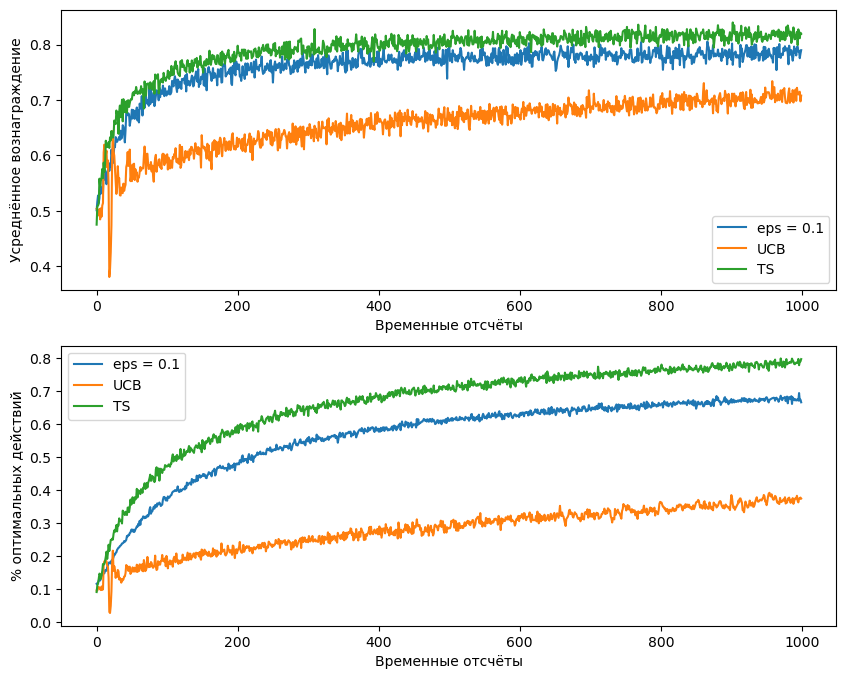

In [38]:
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)
plt.plot(rewards[0], label='eps = %.01f' % (0.1))
plt.plot(rewards[1], label='UCB')
plt.plot(rewards[2], label='TS')
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.01f' % (0.1))
plt.plot(best_action_counts[1], label='UCB')
plt.plot(best_action_counts[2], label='TS')
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Из графиков можно отметить, что стратегия на основе выборки Томпсона проявила себя лучше всего.
Тот факт, что стратегия на основе ВДГ-действия показывает себя на 1000 шагах хуже, чем $\varepsilon$-жадная стратегия можно объяснить тем, что теперь дисперсия вектора истинных ценностей гораздо меньше и нужно накопить достаточно много статистики, чтобы доверительные интервалы позволяли устойчиво выявлять наилучший рычаг. 

Рассмотрим также работу стратегий в нестационарном случае.

In [39]:
runs=2000
time=1000

bandit = Bandit_TS(10, Q_changed = True)

agents = []
agents.append(EpsilonGreedyAgent(bandit, epsilon=0.1, alpha = 0.1))
agents.append(UCBAgent(bandit, alpha = 0.1))
agents.append(ThompsonAgent(bandit))

rewards=np.zeros((len(agents),n_steps))
best_action_counts = np.zeros((len(agents),n_steps))

for i, agent in enumerate(agents):
    rewards[i], best_action_counts[i] = bandit_simulation(bandit, agent, runs, n_steps)

100%|██████████| 2000/2000 [01:11<00:00, 27.86it/s]


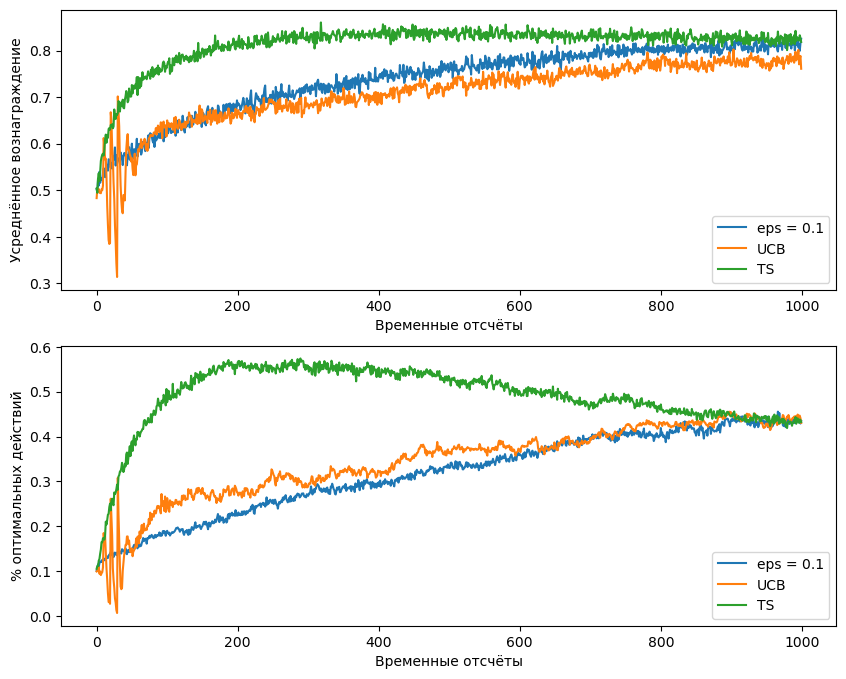

In [40]:
plt.figure(figsize=(10,8))     
plt.subplot(2, 1, 1)
plt.plot(rewards[0], label='eps = %.01f' % (0.1))
plt.plot(rewards[1], label='UCB')
plt.plot(rewards[2], label='TS')
plt.xlabel('Временные отсчёты')
plt.ylabel('Усреднённое вознаграждение')
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(best_action_counts[0], label='eps = %.01f' % (0.1))
plt.plot(best_action_counts[1], label='UCB')
plt.plot(best_action_counts[2], label='TS')
plt.xlabel('Временные отсчёты')
plt.ylabel('% оптимальных действий')
plt.legend()

Здесь $\varepsilon$-жадная стратегия с постоянным шагом обучения по-видимому также демострирует лучшую адаптацию к изменению истинных ценностей. Стратегия на основе выборки Томпсона не позволяет достаточно быстро адаптироваться к изменениям истинных ценностей.